## **Assignment - 5**

Group Details-
1. Akarsh Dubey CS25MTECH14001
2. Atish Kadam CS25MTECH14003

**Problem Statement**
Implement algorithm to find minimum cost max flow in a network.

**Input:** CSV file with 4 rows and number of columns is number of edges.
            Each column corresponds to a edge.
            First row is the 'from' vertex and second row is the 'to' vertex of edges, and third row is the capacity of the edges, and fourth row is the cost of sending one unit flow on that.
           Note that vertex ids are integers.
           Source vertex id is '1' and destination vertex id is '2'
              
**Output:**  You need to print total cost at each iteration.

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog
import heapq
from collections import defaultdict
import matplotlib.pyplot as plt
import sys

In [ ]:
class FlowOptimizationError(Exception):
    pass

class MinCostMaxFlowPrimalDual:
    """
    Reads network structure from CSV file and solves using successive shortest paths.
    """

    def __init__(self, file_path, eps=1e-8):
        """
        Initialize network from CSV file

        CSV format:
        - Row 0: from vertices
        - Row 1: to vertices
        - Row 2: capacities
        - Row 3: costs per unit flow
        """
        try:
            data = pd.read_csv(file_path, header=None)
            if data.shape[0] != 4:
                raise FlowOptimizationError("CSV must have exactly 4 rows.")

            self.from_vertices = data.iloc[0].values.astype(int)
            self.to_vertices = data.iloc[1].values.astype(int)
            self.capacities = data.iloc[2].values.astype(float)
            self.costs = data.iloc[3].values.astype(float)

            self.n = max(max(self.from_vertices), max(self.to_vertices))
            self.m = len(self.from_vertices)
            self.edges = []

            for i in range(self.m):
                self.edges.append((
                    self.from_vertices[i],
                    self.to_vertices[i],
                    self.capacities[i],
                    self.costs[i]
                ))

            self.flow = np.zeros(self.m)
            self.total_cost = 0
            self.total_flow = 0
            self.eps = eps

            self.iteration_log = []
            self.cost_history = []
            self.flow_history = []

            np.set_printoptions(precision=4, suppress=True)

        except Exception as e:
            raise FlowOptimizationError(f"Failed to read network: {e}")


    def compute_dual_potentials(self, source, sink):
        nodes = set()
        for u, v, _, _ in self.edges:
            nodes.add(u)
            nodes.add(v)
        nodes = sorted(list(nodes))
        n_nodes = len(nodes)
        node_to_idx = {node: idx for idx, node in enumerate(nodes)}

        c = np.ones(n_nodes)

        A_ub = []
        b_ub = []

        for idx, (u, v, capacity, cost) in enumerate(self.edges):
            if self.flow[idx] < capacity - self.eps:
                constraint = np.zeros(n_nodes)
                constraint[node_to_idx[v]] = 1
                constraint[node_to_idx[u]] = -1
                A_ub.append(constraint)
                b_ub.append(cost)

            if self.flow[idx] > self.eps:
                constraint = np.zeros(n_nodes)
                constraint[node_to_idx[u]] = 1
                constraint[node_to_idx[v]] = -1
                A_ub.append(constraint)
                b_ub.append(-cost)

        if not A_ub:
            return {node: 0 for node in nodes}

        A_ub = np.array(A_ub)
        b_ub = np.array(b_ub)

        A_eq = np.zeros((1, n_nodes))
        A_eq[0, node_to_idx[source]] = 1
        b_eq = np.array([0])

        bounds = [(None, None) for _ in range(n_nodes)]

        result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                        bounds=bounds, method='highs')

        if result.success:
            potentials = {int(node): result.x[node_to_idx[node]] for node in nodes}
            return potentials
        else:
            return {int(node): 0 for node in nodes}


    def find_shortest_augmenting_path(self, source, sink, residual_graph, potentials):
        dist = {node: float('inf') for node in range(1, self.n + 1)}
        actual_dist = {node: float('inf') for node in range(1, self.n + 1)}
        parent = {}
        dist[source] = 0
        actual_dist[source] = 0

        pq = [(0, source)]
        visited = set()

        while pq:
            d, u = heapq.heappop(pq)

            if u in visited:
                continue

            visited.add(u)

            if u == sink:
                break

            if u not in residual_graph:
                continue

            for v, capacity, cost, idx, direction in residual_graph[u]:
                if v in visited:
                    continue

                reduced_cost = cost - potentials.get(u, 0) + potentials.get(v, 0)

                if dist[u] + reduced_cost < dist[v]:
                    dist[v] = dist[u] + reduced_cost
                    actual_dist[v] = actual_dist[u] + cost
                    parent[v] = (u, capacity, cost, idx, direction)
                    heapq.heappush(pq, (dist[v], v))

        return actual_dist, parent


    def optimize(self, source=1, sink=2, max_iterations=500):
        print("\nMINIMUM COST MAXIMUM FLOW\n ")
        print(f"Source: {source}, Sink: {sink}")
        print(f"Number of vertices: {self.n}")
        print(f"Number of edges: {self.m}")

        print("Starting Algorithm...\n")

        iteration = 0

        for _ in range(max_iterations):
            iteration += 1
            print(f"Iteration: {iteration}")

            potentials = self.compute_dual_potentials(source, sink)

            residual_graph = defaultdict(list)

            for idx, (u, v, capacity, cost) in enumerate(self.edges):
                if self.flow[idx] < capacity - self.eps:
                    residual_capacity = capacity - self.flow[idx]
                    residual_graph[u].append((v, residual_capacity, cost, idx, 'forward'))

                if self.flow[idx] > self.eps:
                    residual_capacity = self.flow[idx]
                    residual_graph[v].append((u, residual_capacity, -cost, idx, 'backward'))

            for u in sorted(residual_graph.keys()):
                for v, cap, cost, idx, direction in residual_graph[u]:
                    reduced = cost - potentials.get(u, 0) + potentials.get(v, 0)

            dist, parent = self.find_shortest_augmenting_path(source, sink, residual_graph, potentials)

            if dist[sink] == float('inf'):
                print(f"No augmenting path found from {source} to {sink}.")
                print("Algorithm terminates.\n")
                break

            path = []
            v = sink
            bottleneck = float('inf')

            while v != source:
                u, capacity, cost, idx, direction = parent[v]
                path.append((u, v, capacity, cost, idx, direction))
                bottleneck = min(bottleneck, capacity)
                v = u

            path.reverse()

            print("Augmenting flow along the path...")
            path_cost = 0

            for u, v, cap, cost, idx, direction in path:
                if direction == 'forward':
                    self.flow[idx] += bottleneck
                    path_cost += bottleneck * cost
                else:
                    self.flow[idx] -= bottleneck
                    path_cost += bottleneck * cost

            self.total_flow += bottleneck
            self.total_cost += path_cost

            print(f"Total flow: {self.total_flow:.2f}")
            print(f"Total cost: {self.total_cost:.2f}")

            self.cost_history.append(self.total_cost)
            self.flow_history.append(self.total_flow)
            self.iteration_log.append((iteration, self.total_cost, self.total_flow, path))
            print()

        print("FINAL RESULTS")
        print("------------------")
        print(f"Maximum Flow: {self.total_flow:.2f}")
        print(f"Minimum Cost: {self.total_cost:.2f}")
        print(f"Number of iterations: {iteration}")


    def calculate_node_layout(self):
        nodes = set()
        for u, v, _, _ in self.edges:
            nodes.add(u)
            nodes.add(v)

        pos = {}
        source = 1
        sink = 2

        from collections import deque
        visited = {source}
        queue = deque([(source, 0)])
        layers = defaultdict(list)

        while queue:
            node, layer = queue.popleft()
            layers[layer].append(node)

            for u, v, _, _ in self.edges:
                if u == node and v not in visited:
                    visited.add(v)
                    queue.append((v, layer + 1))

        max_layer = max(layers.keys()) if layers else 0
        for layer, nodes_in_layer in layers.items():
            x = layer * 3
            n_nodes = len(nodes_in_layer)
            for i, node in enumerate(sorted(nodes_in_layer)):
                y = (i - (n_nodes - 1) / 2) * 2
                pos[node] = (x, y)

        all_nodes = set(range(1, self.n + 1))
        unpositioned = all_nodes - set(pos.keys())
        for i, node in enumerate(sorted(unpositioned)):
            pos[node] = ((max_layer + 1) * 3, i * 2)

        return pos


    def show_network_graph(self, title="Network Graph", flow_values=None):
        pos = self.calculate_node_layout()

        plt.figure(figsize=(7, 5))

        nodes = set()
        for u, v, _, _ in self.edges:
            nodes.add(u)
            nodes.add(v)

        for node in nodes:
            x, y = pos[node]
            if node == 1:
                plt.scatter(x, y, s=800, c='lightgreen', edgecolors='darkgreen', linewidths=3, zorder=5)
                plt.text(x, y, str(node), fontsize=14, fontweight='bold', ha='center', va='center', zorder=6)
            elif node == 2:
                plt.scatter(x, y, s=800, c='lightcoral', edgecolors='darkred', linewidths=3, zorder=5)
                plt.text(x, y, str(node), fontsize=14, fontweight='bold', ha='center', va='center', zorder=6)
            else:
                plt.scatter(x, y, s=600, c='lightblue', edgecolors='darkblue', linewidths=2, zorder=5)
                plt.text(x, y, str(node), fontsize=14, fontweight='bold', ha='center', va='center', zorder=6)

        for idx, (u, v, capacity, cost) in enumerate(self.edges):
            x1, y1 = pos[u]
            x2, y2 = pos[v]

            if flow_values is not None and flow_values[idx] > self.eps:
                flow = flow_values[idx]
                linewidth = 2 + (flow / capacity) * 6
                alpha = 0.9
                color = 'darkblue'
                label_text = f"{flow:.1f}/{capacity:.0f}\ncost={cost:.1f}"
            else:
                linewidth = 1.5
                alpha = 0.4
                color = 'gray'
                label_text = f"cap={capacity:.0f}\ncost={cost:.1f}"

            dx = x2 - x1
            dy = y2 - y1
            plt.arrow(x1, y1, dx * 0.85, dy * 0.85,
                     head_width=0.3, head_length=0.2,
                     fc=color, ec=color, linewidth=linewidth, alpha=alpha, zorder=3)

            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            offset_x = -dy * 0.05 if abs(dy) > 0.1 else 0
            offset_y = dx * 0.05 if abs(dx) > 0.1 else 0.3
            plt.text(mid_x + offset_x, mid_y + offset_y, label_text,
                    fontsize=9, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'),
                    zorder=4)

        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Layer', fontsize=12)
        plt.ylabel('Position', fontsize=12)
        plt.grid(True, alpha=0.2)
        plt.axis('equal')
        plt.tight_layout()
        plt.axis('off')
        plt.show()


    def show_summary(self):
        if not self.iteration_log:
            print("No iteration data available.")
            return

        print("\nITERATION SUMMARY: TOTAL COST AT EACH ITERATION")
        print(f"{'Iteration':<12} {'Flow Added':<15} {'Path Cost':<15} {'Total Flow':<15} {'Total Cost':<15}")

        prev_flow = 0
        prev_cost = 0

        for iteration, total_cost, total_flow, path in self.iteration_log:
            flow_added = total_flow - prev_flow
            path_cost = total_cost - prev_cost
            print(f"{iteration:<12} {flow_added:<15.2f} {path_cost:<15.2f} {total_flow:<15.2f} {total_cost:<15.2f}")
            prev_flow = total_flow
            prev_cost = total_cost

**Main Function**
Instruction -  Before running main function please copy path of file and paste in line 3 of this cell

VISUALIZING NETWORK BEFORE OPTIMIZATION



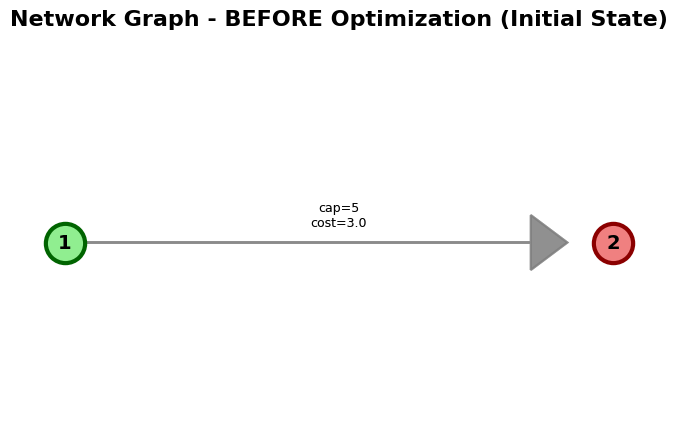


MINIMUM COST MAXIMUM FLOW
 
Source: 1, Sink: 2
Number of vertices: 2
Number of edges: 4
Starting Algorithm...

Iteration: 1
Augmenting flow along the path...
Total flow: 5.00
Total cost: 15.00

Iteration: 2
Augmenting flow along the path...
Total flow: 10.00
Total cost: 30.00

Iteration: 3
Augmenting flow along the path...
Total flow: 15.00
Total cost: 45.00

Iteration: 4
Augmenting flow along the path...
Total flow: 22.00
Total cost: 73.00

Iteration: 5
No augmenting path found from 1 to 2.
Algorithm terminates.

FINAL RESULTS
------------------
Maximum Flow: 22.00
Minimum Cost: 73.00
Number of iterations: 5

ITERATION SUMMARY: TOTAL COST AT EACH ITERATION
Iteration    Flow Added      Path Cost       Total Flow      Total Cost     
1            5.00            15.00           5.00            15.00          
2            5.00            15.00           10.00           30.00          
3            5.00            15.00           15.00           45.00          
4            7.00        

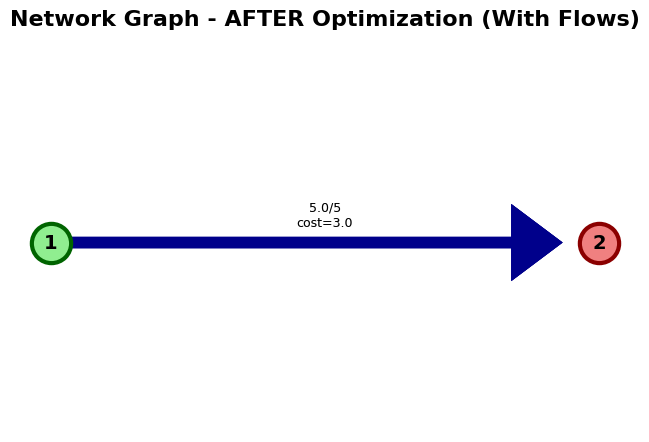

In [ ]:
if __name__ == "__main__":
    try:
        solver = MinCostMaxFlowPrimalDual('/content/Testcase.csv')  ## <--- Please paste path of testcase csv file.
        print("VISUALIZING NETWORK BEFORE OPTIMIZATION\n")

        solver.show_network_graph(title="Network Graph - BEFORE Optimization (Initial State)",
                                  flow_values=None)

        solver.optimize(source=1, sink=2)

        solver.show_summary()

        print("\nVISUALIZING NETWORK AFTER OPTIMIZATION\n")

        solver.show_network_graph(title="Network Graph - AFTER Optimization (With Flows)",
                                  flow_values=solver.flow)

    except FlowOptimizationError as e:
        print(f"[Flow Optimization Error] {e}")
        sys.exit(0)
    except Exception as e:
        print(f"[Unexpected Error] {e}")
        sys.exit(0)